In [1]:
import astroquery # import astroquery
from astroquery.eso import Eso # import the ESO module from astroquery

print(f"astroquery version: {astroquery.__version__}") # check the version of astroquery

eso = Eso() # create an instance of the ESO class 

astroquery version: 0.4.12.dev10525


In [2]:
from astropy.coordinates import SkyCoord # import the SkyCoord class from the astropy.coordinates module
import astropy.units as u # import the astropy.units module

In [3]:
target = "Sgr A*" # set the target to Sgr A*
coords = SkyCoord.from_name(target) # create a SkyCoord object from the name of the source 
radius = 3 *u.arcmin # set the radius of the search to 3 arcminutes

In [9]:
eso.query_region?

Signature:
eso.query_region(
    coordinates,
    radius=None,
    *,
    data: str = 'reduced',
    instrument: str = None,
    column_filters: Optional[dict] = None,
    columns: Union[List, str] = None,
    maxrec: int = None,
    **kwargs,
) -> Union[astropy.table.table.Table, int, str]
Docstring:
Query a cone region around given coordinates.

Parameters
----------
coordinates : str or `astropy.coordinates.SkyCoord` or coordinate-like
    Identifier or coordinates around which to query.
radius : str or `~astropy.units.Quantity`, optional
    Cone search radius. If not provided, defaults to 5 arcmin.
data : {"reduced", "raw"}, optional
    Selects which backend query to use. Default is ``"reduced"``.
instrument : str, optional
    Instrument restriction. Only supported when ``data="raw"``.
column_filters : dict or None, optional
    Constraints applied to the query in ADQL syntax,
    e.g., ``{"exp_start": "between '2024-12-31' and '2025-12-31'"}``.
    Default is ``None``.
columns 

In [18]:
table = eso.query_region(coords, radius=radius, surveys="HAWKI") # query the ESO archive for data within the specified region

In [19]:
for colname in table.colnames: 
    print(colname) # print the names of the columns in the resulting table

target_name
s_ra
s_dec
dp_id
proposal_id
abmaglim
access_estsize
access_format
access_url
bib_reference
calib_level
dataproduct_subtype
dataproduct_type
em_max
em_min
em_res_power
em_xel
facility_name
filter
gal_lat
gal_lon
instrument_name
is_solar
last_mod_date
multi_ob
n_obs
o_calib_status
o_ucd
obs_collection
obs_creator_did
obs_creator_name
obs_id
obs_publisher_did
obs_release_date
obs_title
obstech
p3orig
pol_states
pol_xel
preview_html
publication_date
release_description
s_fov
s_pixel_scale
s_region
s_resolution
s_xel1
s_xel2
snr
strehl
t_exptime
t_max
t_min
t_resolution
t_xel


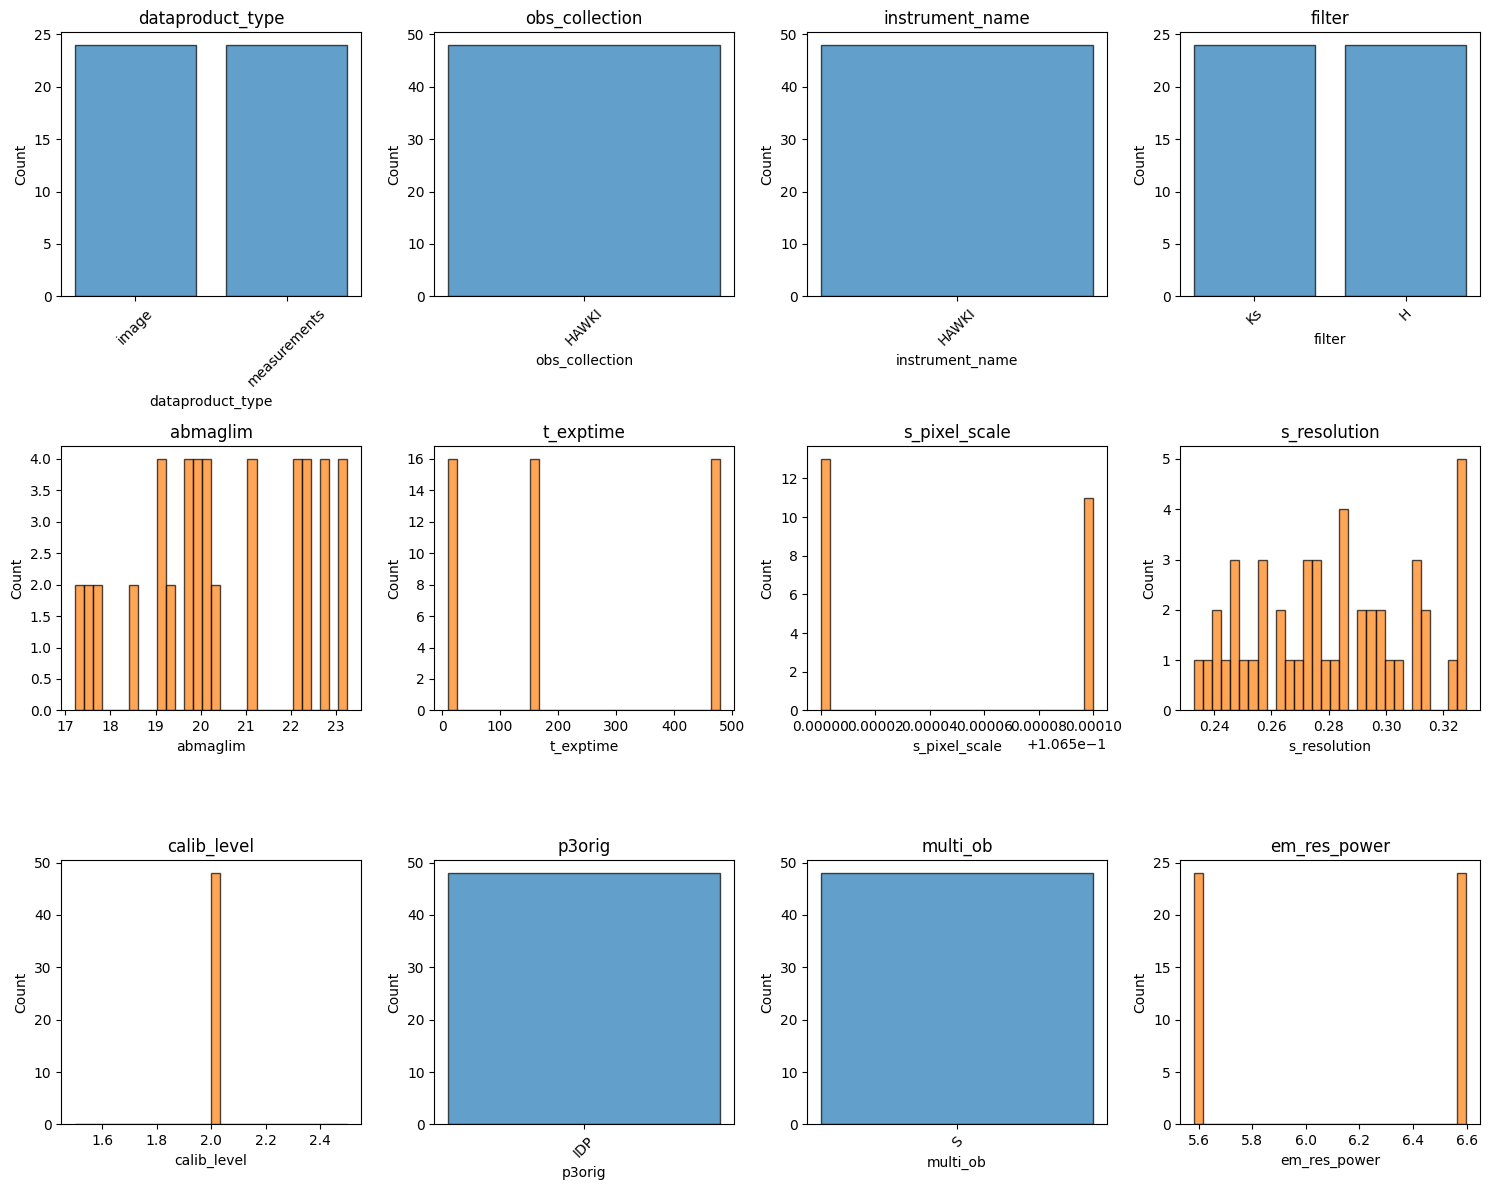

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Define columns to plot
columns = [
    "dataproduct_type", "obs_collection", "instrument_name", "filter", "abmaglim",
      "t_exptime", "s_pixel_scale", "s_resolution", "calib_level", "p3orig", 
    "multi_ob", "em_res_power"
]

# Prepare plot grid
n = len(columns)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

# Loop over each column
for ax, col in zip(axes, columns):
    data = table[col]
    
    # Remove masked or NaN values
    if np.ma.is_masked(data):
        data = data[~data.mask]
    data = data[~np.isnan(data)] if data.dtype.kind in 'f' else data  # remove NaNs from floats

    # Check if numeric or categorical
    if data.dtype.kind in 'biufc':  # numeric
        ax.hist(data, bins=30, color='C1', edgecolor='black', alpha=0.7)
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
    else:  # categorical
        counts = Counter(data)
        labels, values = zip(*counts.most_common())
        ax.bar(labels, values, color='C0', edgecolor='black', alpha=0.7)
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.tick_params(axis='x', rotation=45)

    ax.set_title(col)

# Hide any unused subplots
for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()